# Disease State Geodesics

In this notebook we provide the theory and algorithm to shoot a geodesic between two points in different states of disease.

We consider first the phase space of vector fields

In [ ]:
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.lines import Line2D
import matplotlib
from scipy.spatial.distance import pdist
SAVE = False
def plot_umap(df, disease_label, labels, palette_dict, reduction='umap', endotype_matching=False,
               figure_size=(8,6), marker_size=40, save_path=None, alpha=0.8, lw=0.1, fontsize=12, eps=5.0, min_samples=50,
                largest_cluster_arrows=True, explained_var=None):


    fig, ax = plt.subplots(figsize=figure_size, dpi=300 if SAVE else 100)
    hue_vals = labels
    sns.scatterplot(data=df, x='x', y='y', hue=hue_vals, palette=palette_dict, s=marker_size, alpha=alpha, ax=ax, linewidth=lw, zorder=1)# edgecolor='k'

    #ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.2, color='k', zorder=0)
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    #if explained_var is not None:
    #    ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=fontsize+1)
    #    ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=fontsize+1)
    surround_border = 3
    ax.set_xlim(df['x'].quantile(.01)-surround_border, df['x'].quantile(.99)+surround_border)
    ax.set_ylim(df['y'].quantile(.01)-surround_border, df['y'].quantile(.99)+surround_border)

    # quiver phase space
    x_min,x_max=df['x'].min()-surround_border,df['x'].max()+surround_border
    y_min,y_max=df['y'].min()-surround_border,df['y'].max()+surround_border
    n=15;xg=np.linspace(x_min,x_max,n);yg=np.linspace(y_min,y_max,n);X,Y=np.meshgrid(xg,yg)
    #ax.quiver(X,Y,np.full_like(X,v[0]),np.full_like(Y,v[1]),color='k',alpha=0.15,
    #        scale_units='xy',scale=1.5,width=0.003,headwidth=3,headlength=5,
    #        headaxislength=4,zorder=-100)
    
    plt.close()
    return X, Y

    ax.set_title(' '.join(disease_label.split('_')).title().replace('Covid', 'COVID')+ f" $n = {df.__len__()}$", fontsize=fontsize+1)
    plt.tight_layout()
    if SAVE:
        plt.savefig(f"../figures/figure5/{disease_label}_gradient_flow.svg", dpi=300, transparent=True)
        plt.savefig(f"../figures/figure5/png/{disease_label}_gradient_flow.png", dpi=300, transparent=False)
    plt.show()
    return ax

Gradients: 100%|██████████| 225/225 [00:00<00:00, 1287.58it/s]
/tmp/ipykernel_2753725/550210286.py:57: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  sns.scatterplot(data=df, x='x', y='y', hue=df['disease'], palette=sns.color_palette('Paired'), s=2, alpha=.1, ax=ax, linewidth=0, zorder=1)# edgecolor='k'


NameError: name 'FancyArrowPatch' is not defined

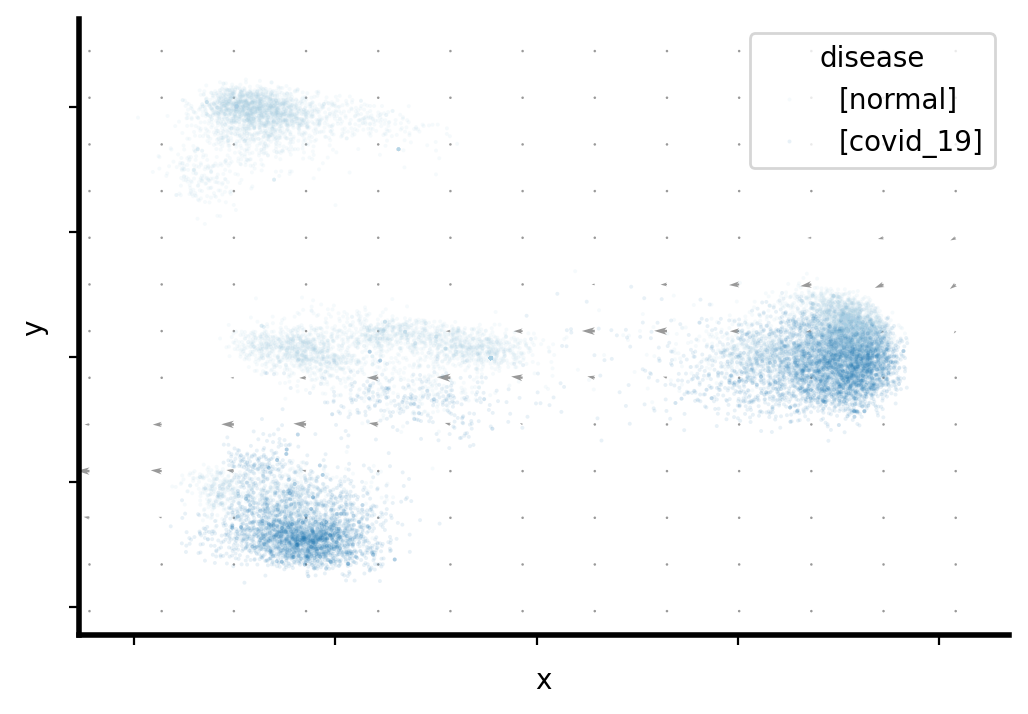

In [ ]:
import os
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
SAVE = False
fontsize = 12

DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiometabolic': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']}
import sys
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
mod, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
disease_list = sum(list(DISEASES_DICT.values()), [])

decoder = mod.prediction_head
device = "cuda:0"
import torch
from torch.nn.functional import softmax
from tqdm import tqdm
from sklearn.decomposition import PCA
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch

df = None
for file_path in os.listdir(EMBEDDINGS_DIR):
    if not file_path.__contains__("embeddings.pkl"): continue
    embeddings = pd.read_pickle(EMBEDDINGS_DIR + file_path)
    df = pd.DataFrame({'embedding': embeddings[0].tolist()} | {tok.phenotypic_types[idx]:embeddings[2][:, idx] for idx in range(len(tok.phenotypic_types))})
    disease_list = sorted(df['disease'].unique().tolist(), key=lambda x: 0 if 'normal' in x else 1) 
    proj = PCA(2)
    df[['x', 'y']] = proj.fit_transform(np.array(df['embedding'].tolist())).tolist()
    surround_border = 3
    x_min,x_max=df['x'].min()-surround_border,df['x'].max()+surround_border
    y_min,y_max=df['y'].min()-surround_border,df['y'].max()+surround_border
    n_grad = 15
    xg,yg = np.linspace(x_min,x_max,n_grad), np.linspace(y_min,y_max,n_grad)
    X, Y = np.meshgrid( xg, yg)
    phase_space_pca_coordinates = np.stack([X, Y], axis=-1).reshape(-1, 2)
    phase_space_embeddings = proj.inverse_transform(phase_space_pca_coordinates)
    
    gradients_per_embedding = []
    for embedding in tqdm(phase_space_embeddings, "Gradients"):
        embedding = torch.tensor(embedding, device=device, dtype=torch.float32).requires_grad_(True)
        prob = softmax(decoder(embedding.unsqueeze(0)), dim=1).squeeze()
        gradients = []
        for disease in disease_list: 
            prob_y =  prob[tok.token_to_id_map[normalise_str(disease)]]
            decoder.zero_grad()
            prob_y.backward(retain_graph=True)
            gradients.append( embedding.grad.detach().cpu().numpy() )
            embedding.grad.zero_()
        gradients_per_embedding.append(np.array(gradients))
    phase_space_gradients = proj.fit_transform(np.array(gradients_per_embedding).reshape(-1, phase_space_embeddings.shape[-1])
                                               ).reshape(phase_space_embeddings.shape[0], len(disease_list), -1).reshape(n_grad, n_grad, len(disease_list), 2)
    # gradients is in (n_grad, n_grad, diseases, 2)
    fig, ax = plt.subplots(figsize=(6,4), dpi=300 if SAVE else 200)
    sns.scatterplot(data=df, x='x', y='y', hue=df['disease'], palette=sns.color_palette('Paired'), s=2, alpha=.1, ax=ax, linewidth=0, zorder=1)# edgecolor='k'
    ax.quiver(X,Y,phase_space_gradients[:, :, 1, 0],phase_space_gradients[:, :, 1, 1],color='k',alpha=0.4,
            scale_units='xy',scale=1.5,width=0.003,headwidth=3,headlength=5,
            headaxislength=4,zorder=-100)
    
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.set_xlim(df['x'].quantile(.01)-surround_border, df['x'].quantile(.99)+surround_border)
    ax.set_ylim(df['y'].quantile(.01)-surround_border, df['y'].quantile(.99)+surround_border)
    arrow_proxy = FancyArrowPatch((0, 0), (1, 0), arrowstyle='-|>', mutation_scale=15, color='black', linewidth=1)
    def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
        return FancyArrowPatch((0, height*0.5), (width, height*0.5), arrowstyle='-|>', mutation_scale=fontsize, color='black', linewidth=1)
    handles, legend_labels_ = ax.get_legend_handles_labels()
    handles.append(arrow_proxy)
    legend_labels_.append(f"Gradient Flow")
    legend_labels_ = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in legend_labels_]

    legend = ax.legend(np.array(handles).tolist(), np.array(legend_labels_).tolist(), frameon=False, loc='best', borderaxespad=1, edgecolor='lightgrey', framealpha=0.9,
                         fontsize=fontsize-2) #
 
    legend = ax.legend()    
    for handle in legend.legendHandles:
        if hasattr(handle, "set_markersize"):
            handle.set_markersize(6) 
            handle.set_alpha(1)
    plt.show()



    #df['gradients'] = gradients_per_embedding
    
    break